<a href="https://colab.research.google.com/github/emsofjames2003/CB2330-exercises/blob/main/project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project card

**The paper**:

##Mossong et al. (2008), Social Contacts and Mixing Patterns Relevant to the Spread of Infectious Diseases.

https://doi.org/10.1371/journal.pmed.0050074

**The data object**: table 1: number of participants, mean, standard deviation and relative number of reported contacts.

**The random variable chosen**: X = total number of social contacts under one day reported by an average individual

**What the paper does**: The paper presents a population-based prospective survey, where 7290 participants recorded their mixing patterns (social contacts)for one day. Different types of contacts were identified, and different parameters are associated with different average rates of contact. The categories recorded were age, day of the week, gender, country, and household size.

The purpose of the survey is to allow modelling of transmission of infectious diseases that spread through close-contact.

The authors used negative binomial regression to analyse contact counts.

**The generative model proposed**: Negative Binomial Distribution

We chose this as contacts are independent from each other. The rates of daily contacts also from person to person, even within the same age groups. A negative binomial distribution allows for this variation.

To simulate one participant, we draw one contact count from the negative binomial distribution for their age group. We repeat this for all participants.

We use the same model for both age groups, with separate parameter values.

**Parameters and assumptions**:  θ = age. We assume that age is the most important predictor of the mean daily contact rate.

**The forward simulation**:

**The parametrization/fitting**:

**What/if the model adds to the paper**:

**Model limitations/how it breaks**: The limitation of our model is that we only include age, and leave out other important factors, such as household size, day of week, gender, and country.

**Table 1**
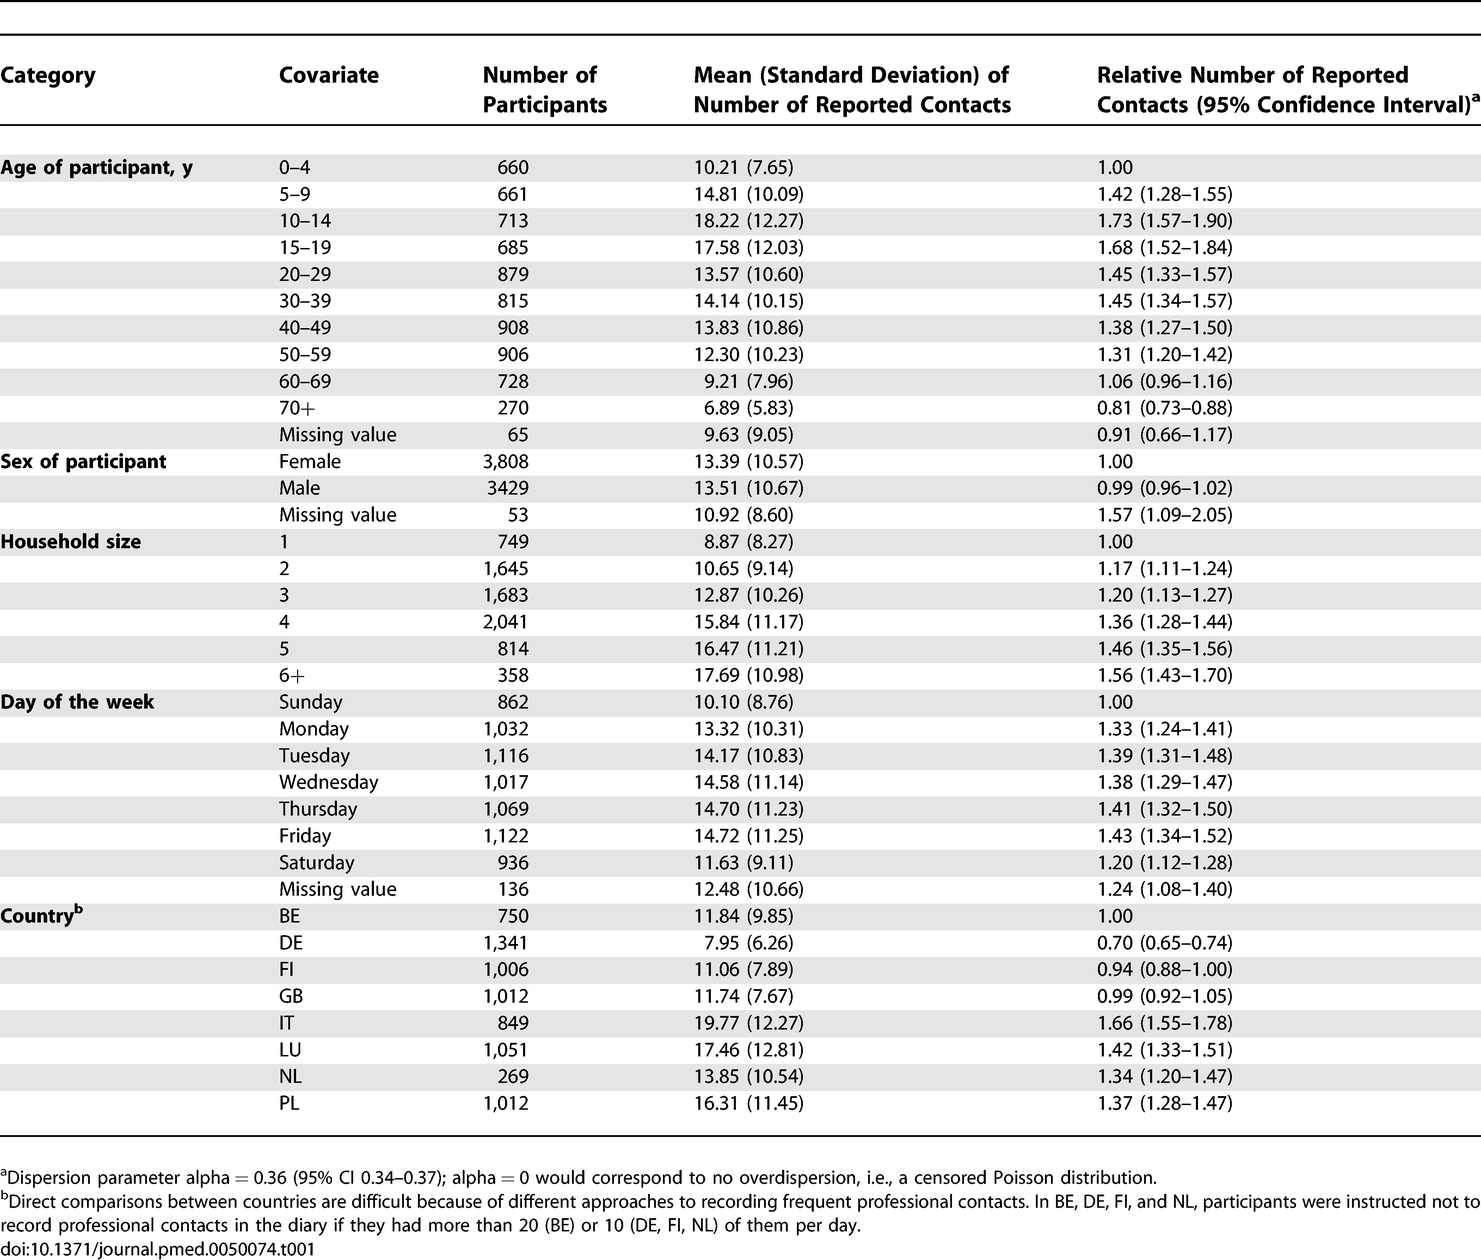

In [9]:
import math
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

Our data:

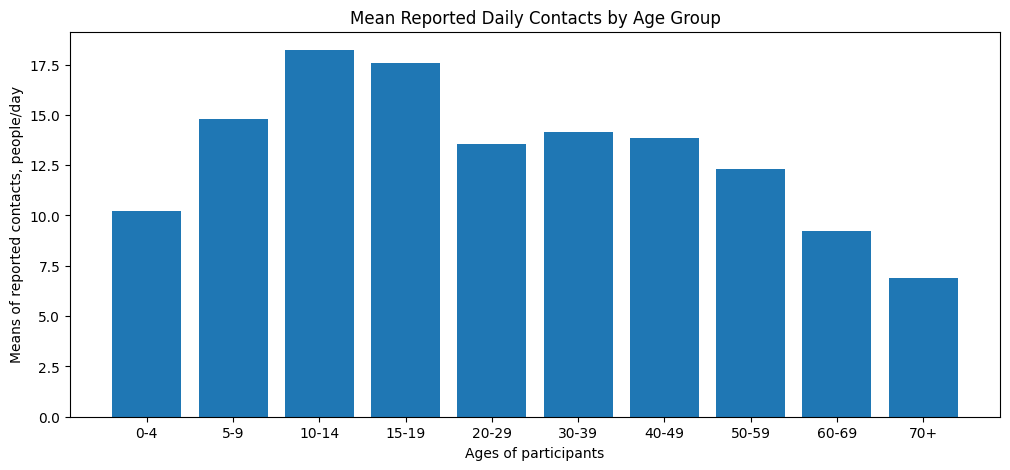

In [39]:
# The original reported contacts/ age distribution:
ages = ("0-4", "5-9", "10-14", "15-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70+")
sizes = [660, 661, 713, 685, 879, 815, 908, 906, 728, 270] # number of participants
means = [10.21, 14.81, 18.22, 17.58, 13.57, 14.14, 13.83, 12.30, 9.21, 6.89] # means per age
sd = [7.65, 10.09, 12.27, 12.03, 10.60, 10.15, 10.86, 10.23, 7.96, 5.83] # standard deviation per age

plt.figure(figsize= (12, 5))
plt.bar(ages, means)
plt.xlabel("Ages of participants")
plt.ylabel("Means of reported contacts, people/day")
plt.title("Mean Reported Daily Contacts by Age Group")
plt.show()

We will leave out the missing value column.

Calculate weighted mean, standard deviation, variance and NB size r

In [5]:
N_total = sum(sizes) # Total participants - missing values for age

# Pooled weighted mean
pooled_mean = sum(m * s for m, s in zip(means, sizes))/sum(sizes)

# Pooled weighted variance within age groups
var = [s ** 2 for s in sd] # s^2
df = [n - 1 for n in sizes] # degrees of freedom (= values free to vary)
within_var = sum(d * v for d, v in zip(df, var)) / sum(df)
# Pooled weighted variance, s_p^2 between age groups
between_var = sum(n * (m-pooled_mean)**2 for m, n in zip(means, sizes))/N_total

# Total population variance
total_var = within_var + between_var

# Pooled weighted standard deviation
pooled_sd = (total_var)**0.5

# Negative binomial size r = mu^2/(var-mu)
r = pooled_mean**2/(total_var-pooled_mean)

print(f"Population Pooled Mean: {pooled_mean:.2f}")
print(f"Population Grand Variance: {total_var:.2f}")
print(f"Negative Binomial size r: {r:.4f}")


Population Pooled Mean: 13.46
Population Grand Variance: 112.79
Negative Binomial size r: 1.8253


Forward simulation

In [18]:
all_simulated_contacts = []

# Look through individual age groups
for age_label, group_size, m, s in zip(ages, sizes, means, sd):
  group_var = s ** 2 # calculated variance for individual age groups

# Negative binomial parameters for the group
# Method of moments: r = mean ^2 / (var - mean)
  r_group = (m ** 2) / (group_var - m)
  p_group = r_group / (r_group + m)

# Simulate contact count for every individual in group
  group_simulated_contacts = stats.nbinom.rvs(n=r_group, p=p_group, size=int(group_size))
  all_simulated_contacts.extend(group_simulated_contacts)

# For evert individual in age group
  print(f"Age  {age_label:<6} | Simulated {group_size:<3} individuals | Simulated mean: {np.mean(group_simulated_contacts):.1f}")


Age  0-4    | Simulated 660 individuals | Simulated mean: 10.1
Age  5-9    | Simulated 661 individuals | Simulated mean: 15.0
Age  10-14  | Simulated 713 individuals | Simulated mean: 18.1
Age  15-19  | Simulated 685 individuals | Simulated mean: 17.9
Age  20-29  | Simulated 879 individuals | Simulated mean: 13.3
Age  30-39  | Simulated 815 individuals | Simulated mean: 14.4
Age  40-49  | Simulated 908 individuals | Simulated mean: 13.6
Age  50-59  | Simulated 906 individuals | Simulated mean: 12.4
Age  60-69  | Simulated 728 individuals | Simulated mean: 9.4
Age  70+    | Simulated 270 individuals | Simulated mean: 6.7


Entire simulated populations distribution

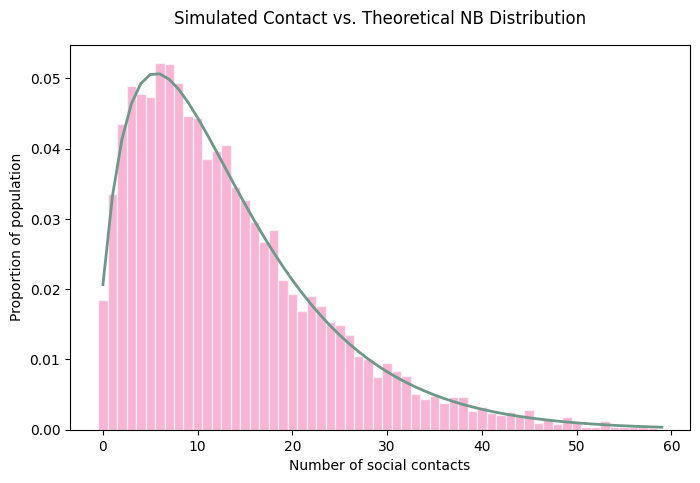

In [38]:
plt.figure(figsize=(8, 5))

# Histogram
counts, bins, ignored = plt.hist(
    all_simulated_contacts,
    bins=np.arange(0, 60) - 0.5, # Centers the bars over the integers
    density=True,
    alpha=0.6,
    color='#F283B6',
    edgecolor='white',
    label='Simulated Population (All Ages)'
)

# Theoretical PMF
p_pooled = r / (r + pooled_mean)
x_values = np.arange(0, 60)
theoretical_pmf = stats.nbinom.pmf(x_values, n=r, p=p_pooled)

# Negative binomial curve
plt.plot(x_values, theoretical_pmf, color='#6E9887', lw=2, markersize=4, label='Theoretical negative binomial curve')
plt.title('Simulated Contact vs. Theoretical NB Distribution', fontsize=12, pad=15)
plt.xlabel('Number of social contacts', fontsize=10)
plt.ylabel('Proportion of population', fontsize=10)
plt.show()


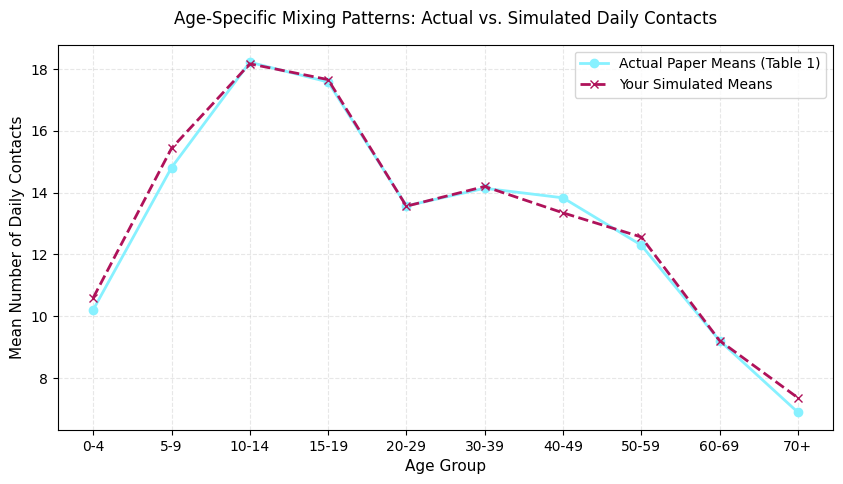

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate the average contact count for each age group from your simulation
simulated_means = []
for age_label, group_size, m, s in zip(ages, sizes, means, sd):
    # This recalculates the parameters exactly like your loop did
    group_var = s ** 2
    r_group = (m ** 2) / (group_var - m)
    p_group = r_group / (r_group + m)

    # Generate a sample to get the simulated mean for this specific plot
    group_sim = stats.nbinom.rvs(n=r_group, p=p_group, size=int(group_size))
    simulated_means.append(np.mean(group_sim))

# 2. Plot the comparison
plt.figure(figsize=(10, 5))

# Plot actual means from Mossong et al.
plt.plot(ages, means, marker='o', linewidth=2, color='#87F1FF', label='Actual Paper Means (Table 1)')

# Plot your simulation's means
plt.plot(ages, simulated_means, marker='x', linestyle='--', linewidth=2, color='#AF125A', label='Your Simulated Means')

# 3. Styling the chart
plt.title('Age-Specific Mixing Patterns: Actual vs. Simulated Daily Contacts', fontsize=12, pad=15)
plt.xlabel('Age Group', fontsize=11)
plt.ylabel('Mean Number of Daily Contacts', fontsize=11)
plt.grid(axis='both', alpha=0.3, linestyle='--')
plt.legend(frameon=True)

plt.show()


Backwards simulation: observed data --> estimate parameters


*  Bootstrapping, as we only have summary statistics from paper.



<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_6334/3705357196.py:44: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_title('Backward Recovery: Population Mean ($\mu$)')


Running backward simulation via bootstrapping...


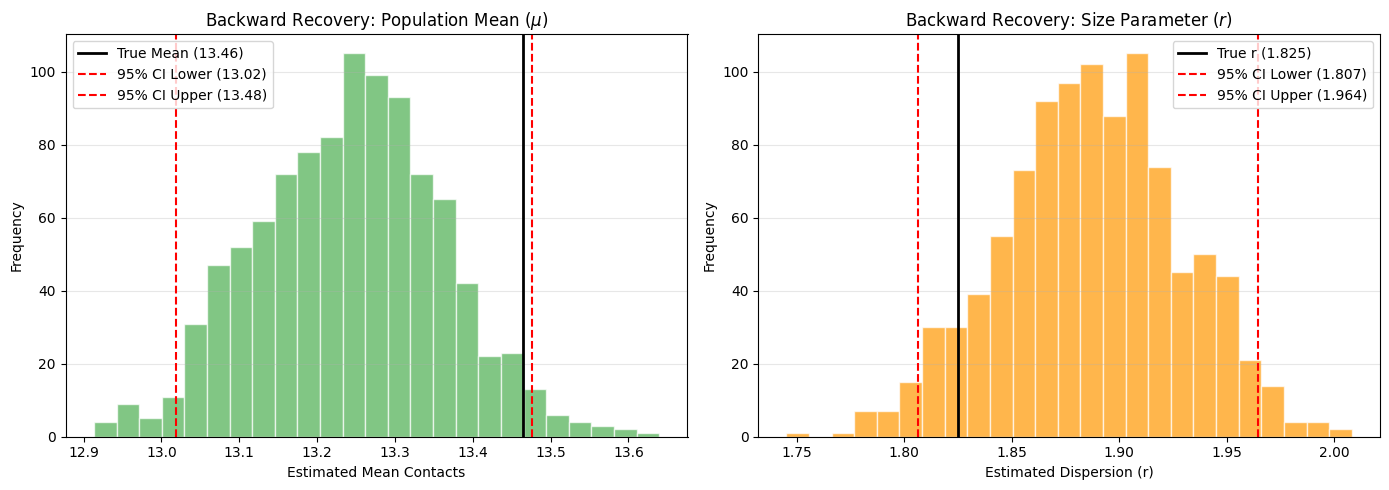


--- Backward Simulation Report ---
True Population Mean: 13.46 | Recovered Bootstrap 95% CI: [13.02, 13.48]
True Dispersion Size r: 1.825 | Recovered Bootstrap 95% CI: [1.807, 1.964]


In [45]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Number of bootstrap repetitions
n_bootstraps = 1000

# Containers to store our bootstrap parameter estimates
bootstrapped_means = []
bootstrapped_rs = []

# --- 1. Generate our baseline 'observed' data (using your pooled population logic)
p_pooled = r / (r + pooled_mean)
observed_population = stats.nbinom.rvs(n=r, p=p_pooled, size=int(N_total), random_state=42)

# --- 2. Run the Bootstrap Loop (Backward Simulation)
print("Running backward simulation via bootstrapping...")
for _ in range(n_bootstraps):
    # Resample the population with replacement
    bootstrap_sample = np.random.choice(observed_population, size=len(observed_population), replace=True)

    # Calculate sample moments from the bootstrap draw
    sample_mean = np.mean(bootstrap_sample)
    sample_var = np.var(bootstrap_sample)

    # Reconstruct the parameters (Backward Inference)
    sample_r = (sample_mean ** 2) / (sample_var - sample_mean) if sample_var > sample_mean else np.nan

    bootstrapped_means.append(sample_mean)
    bootstrapped_rs.append(sample_r)

# --- 3. Calculate 95% Confidence Intervals (2.5th to 97.5th percentiles)
ci_mean = np.percentile(bootstrapped_means, [2.5, 97.5])
ci_r = np.percentile(bootstrapped_rs, [2.5, 97.5])

# --- 4. Plot the Backward Simulation Results Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Bootstrap Distribution of recovered Means
axes[0].hist(bootstrapped_means, bins=25, color='#4CAF50', alpha=0.7, edgecolor='white')
axes[0].axvline(pooled_mean, color='black', linestyle='-', linewidth=2, label=f'True Mean ({pooled_mean:.2f})')
axes[0].axvline(ci_mean[0], color='red', linestyle='--', label=f'95% CI Lower ({ci_mean[0]:.2f})')
axes[0].axvline(ci_mean[1], color='red', linestyle='--', label=f'95% CI Upper ({ci_mean[1]:.2f})')
axes[0].set_title('Backward Recovery: Population Mean ($\mu$)')
axes[0].set_xlabel('Estimated Mean Contacts')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot B: Bootstrap Distribution of recovered Dispersion Parameter (r)
axes[1].hist(bootstrapped_rs, bins=25, color='#FF9800', alpha=0.7, edgecolor='white')
axes[1].axvline(r, color='black', linestyle='-', linewidth=2, label=f'True r ({r:.3f})')
axes[1].axvline(ci_r[0], color='red', linestyle='--', label=f'95% CI Lower ({ci_r[0]:.3f})')
axes[1].axvline(ci_r[1], color='red', linestyle='--', label=f'95% CI Upper ({ci_r[1]:.3f})')
axes[1].set_title('Backward Recovery: Size Parameter ($r$)')
axes[1].set_xlabel('Estimated Dispersion (r)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print formal reporting metrics
print("\n--- Backward Simulation Report ---")
print(f"True Population Mean: {pooled_mean:.2f} | Recovered Bootstrap 95% CI: [{ci_mean[0]:.2f}, {ci_mean[1]:.2f}]")
print(f"True Dispersion Size r: {r:.3f} | Recovered Bootstrap 95% CI: [{ci_r[0]:.3f}, {ci_r[1]:.3f}]")


Fitting

In [ ]:
# Try to get distribution closer to the bar graph.